# Predicao de modelo

In [63]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import random_split, DataLoader, Subset
import os
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np

import importlib


In [37]:
from importlib import reload
import efficientUnet
import CerraDataDataset

reload(efficientUnet)
reload(CerraDataDataset)


<module 'CerraDataDataset' from '/home/sabrina/Documents/GitHub/projectsUFV/CNN_CV/CerraDataDataset.py'>

In [26]:
# Load the EfficientUNet model

path_model_without = Path(r'/home/sabrina/Documents/DocUFV/INF692/outputs_20250629_121352_RGB_NIR_NDVI_EVI2_SAVI/best_model.pth')
path_model_with    = Path(r'/home/sabrina/Documents/DocUFV/INF692/outputs_20250630_145344_with/best_model.pth')

In [27]:
# Get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [38]:
# Load the best model
model_with = efficientUnet.EfficientUNet(num_classes=7, in_channels=7, pretrained=True)
model_with.load_state_dict(torch.load(path_model_with, map_location=device))

model_with.to(device)
model_with.eval()


# Load the best model without additional channels
model_without = efficientUnet.EfficientUNet(num_classes=7, in_channels=7, pretrained=False)
model_without.load_state_dict(torch.load(path_model_without, map_location=device))
model_without.to(device)
model_without.eval()

EfficientUNet(
  (encoder): EfficientNetFeatures(
    (conv_stem): Conv2d(7, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
          (bn1): BatchNormAct2d(
            40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (

In [29]:
dataset_path = Path(r'/home/sabrina/Documents/Datasets/cerradata_4mm/')
batch_size = 64


In [39]:

# Carregar dataset
dataset = CerraDataDataset.CerraDataset(
    cam_dir=dataset_path, 
    dispositivo=device, 
    normalizacao='0a1', 
    transformar=transforms
)

# Dividir em treino e validação
razao_treino = 0.8
tam_treino = int(razao_treino * len(dataset))
tam_val   = len(dataset) - tam_treino

train_dataset, val_dataset = random_split(
    dataset, 
    [tam_treino, tam_val], 
    generator=torch.Generator().manual_seed(42)
)

# Dataloader para validação
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    #num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
    drop_last=False
)

In [103]:
# Load 3 images from the validation set
val_images = []
selected_indices = np.random.choice(len(val_dataset), 3, replace=False)
for idx in selected_indices:
    image, label = val_dataset[idx]
    val_images.append((image, label))

In [76]:
# predict function
def predict(model, images):
    model.eval()
    with torch.no_grad():
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
    return preds.cpu().numpy()

In [91]:
# predict the images
images_tensor = torch.stack([img for img, _ in val_images]).to(device)
predictions_with = predict(model_with, images_tensor)
predictions_without = predict(model_without, images_tensor)

In [93]:
classes_names = ['Pasture', 'Arboreal', 'Agriculture', 'Mining', 'Building', 'Water', 'Other']

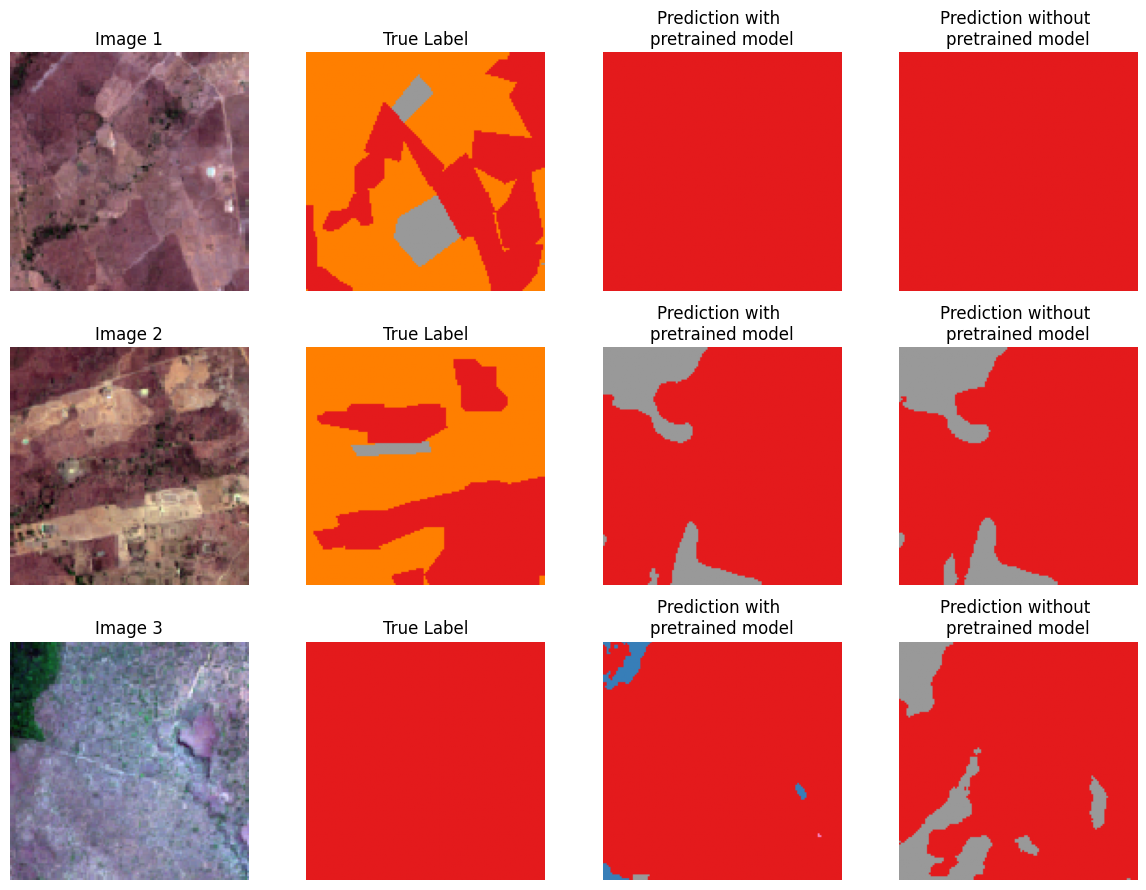

In [109]:
# Visualize the predictions
# Convert predictions to images for visualization
# Parameters
colors = "Set1"  # Use a colormap suitable for categorical data
num_samples = len(val_images)

# Create a single figure
fig, axes = plt.subplots(nrows=num_samples, ncols=4, figsize=(12, 3 * num_samples))

if num_samples == 1:
    axes = [axes]  # ensure it's iterable if only one sample

for i, (image, label) in enumerate(val_images):
    rgb_img = image.permute(1, 2, 0).cpu().numpy()[:, :, [2, 1, 0]]  # RGB

    axes[i][0].imshow(rgb_img)
    axes[i][0].set_title(f'Image {i+1}')
    axes[i][0].axis('off')

    axes[i][1].imshow(label.cpu().numpy(), cmap=colors)
    axes[i][1].set_title('True Label')
    axes[i][1].axis('off')

    axes[i][2].imshow(predictions_with[i], cmap=colors)
    axes[i][2].set_title('Prediction with \npretrained model')
    axes[i][2].axis('off')

    axes[i][3].imshow(predictions_without[i], cmap=colors)
    axes[i][3].set_title('Prediction without \npretrained model')
    axes[i][3].axis('off')

plt.tight_layout() 

output_path = Path(r'/home/sabrina/Documents/DocUFV/INF692/predictions/predictions.png')
fig.savefig(output_path, bbox_inches='tight', dpi=300, transparent=True)
# Save as pdf
fig.savefig(output_path.with_suffix('.pdf'), bbox_inches='tight', dpi=300, transparent=True)
plt.show()
